# TP Final - PINN para la ecuacion de Helmholtz 2D (TensorFlow / Keras)

Replicamos (de forma simplificada) la primera mejora del paper:

> **Wang, Teng, Perdikaris** (2021).
> *Understanding and Mitigating Gradient Pathologies in Physics-Informed Neural Networks.*

El paper propone dos mejoras a las PINN. **Nosotros replicamos solo la primera**: un balance adaptativo de los gradientes (`learning rate annealing`). Ademas agregamos una **extension propia (M3)**: una variante que impone la condicion de borde por construccion (tecnica de Lagaris 1998).

## Que vamos a hacer

1. **Setup** - importamos las librerias.
2. **El problema** - la ecuacion de Helmholtz 2D y la solucion exacta que vamos a aprender.
3. **Samplers** - como elegimos los puntos para entrenar.
4. **La red** - un MLP comun (Keras `Sequential`).
5. **Derivadas con GradientTape** - el truco para calcular derivadas automaticas en TF.
6. **Experimento M1** - PINN baseline sin balance (a ver que pasa).
7. **Experimento M2** - la misma PINN PERO con el balance del paper.
8. **Extension M3 (propia)** - PINN con condicion de borde impuesta por construccion.
9. **Experimento FD** - el solver clasico de diferencias finitas (control).
10. **Corte 1D y 3D** - comparacion visual de los cuatro metodos.
11. **Resumen final** - tabla con todos los errores.

> El **grid search de hiperparametros** vive en un notebook aparte (`Grid_Search.ipynb`) para no mezclar cosas.


# 1. Setup

Las librerias que usamos:

- **numpy** — cuentas y arrays.
- **tensorflow + keras** — la red neuronal, el optimizador (Adam) y las derivadas automaticas (`GradientTape`).
- **matplotlib** — graficos.
- **scipy.sparse** — solo para el solver de diferencias finitas (matrices dispersas + sistema lineal).


In [73]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# TF imprime muchos warnings que no nos importan; los silenciamos.
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel("ERROR")

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.19.0
Keras: 3.11.3


In [74]:
# Fijamos las semillas para que cada vez que corramos el notebook salga lo mismo.
np.random.seed(0)
tf.random.set_seed(0)
keras.utils.set_random_seed(0)   # cubre numpy + random de python + TF de una sola vez


# 2. El problema

Resolvemos la **ecuacion de Helmholtz en 2D** en el cuadrado $[-1, 1] \times [-1, 1]$:

$$\Delta u + \lambda \, u \;=\; q(x, y)$$

donde $\Delta u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}$ es el Laplaciano.

Condicion de borde (Dirichlet): $u = 0$ en los 4 lados del cuadrado.

### Truco: fabricamos la solucion

Para poder medir el error de la red, **inventamos** la solucion exacta:

$$u_{\text{exacta}}(x, y) \;=\; \sin(\pi x)\,\sin(4\pi y)$$

Esta funcion ya vale 0 en los bordes (porque $\sin(\pm\pi) = 0$ y $\sin(\pm 4\pi)=0$), asi que cumple la condicion de borde sola.

### De donde sale el forcing $q$

Si reemplazamos $u_{\text{exacta}}$ en la PDE y derivamos dos veces a mano:

$$q(x, y) \;=\; \big(-\pi^2 - (4\pi)^2 + \lambda\big)\,u_{\text{exacta}} \;\approx\; -167 \cdot u_{\text{exacta}}$$

> **Importante**: el forcing $q$ es **~167 veces** mas grande que $u$. Esa magnitud rompe a las PINN sin balance.


In [75]:
# Constantes (vienen del paper, no las tocamos).
LAMBDA = 1.0    # parametro de la PDE
A1 = 1.0        # frecuencia en x  (1 oscilacion)
A2 = 4.0        # frecuencia en y  (4 oscilaciones -> esto es lo que vuelve duro al problema)


In [76]:
# Solucion exacta. Recibe un array de N puntos (N, 2) y devuelve (N, 1).
def u_exacta(x):
    return np.sin(A1 * np.pi * x[:, 0:1]) * np.sin(A2 * np.pi * x[:, 1:2])


In [77]:
# Forcing q analitico. Sale de derivar u_exacta a mano dos veces.
#   q = u_xx + u_yy + lambda * u = (-pi^2 - (4 pi)^2 + lambda) * u_exacta
def forcing(x):
    factor = -(A1 * np.pi)**2 - (A2 * np.pi)**2 + LAMBDA
    return factor * u_exacta(x)


Veamos como se ven la solucion exacta y el forcing sobre una grilla densa de 100x100 puntos.

In [78]:
# Armamos una grilla 100x100 sobre el dominio [-1, 1]^2.
n = 100
x_eje = np.linspace(-1, 1, n)
y_eje = np.linspace(-1, 1, n)
X1, X2 = np.meshgrid(x_eje, y_eje)
puntos = np.column_stack([X1.flatten(), X2.flatten()])   # (10000, 2) -> la usaremos para evaluar

# Evaluamos la solucion exacta y el forcing en toda la grilla.
u_real_2d = u_exacta(puntos).reshape(n, n)
q_real_2d = forcing(puntos).reshape(n, n)


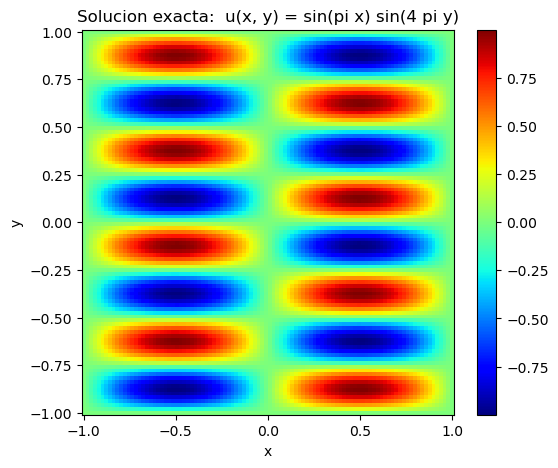

In [79]:
plt.figure(figsize=(6, 5))
plt.pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.title("Solucion exacta:  u(x, y) = sin(pi x) sin(4 pi y)")
plt.show()


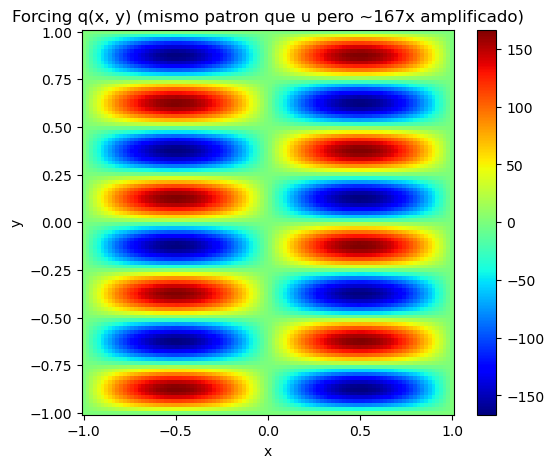

In [80]:
plt.figure(figsize=(6, 5))
plt.pcolormesh(X1, X2, q_real_2d, cmap="jet", shading="auto")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.title("Forcing q(x, y) (mismo patron que u pero ~167x amplificado)")
plt.show()


## Vista 3D de la solucion exacta

La misma funcion en 3D. Se ven mejor las 4 oscilaciones a lo largo del eje y.


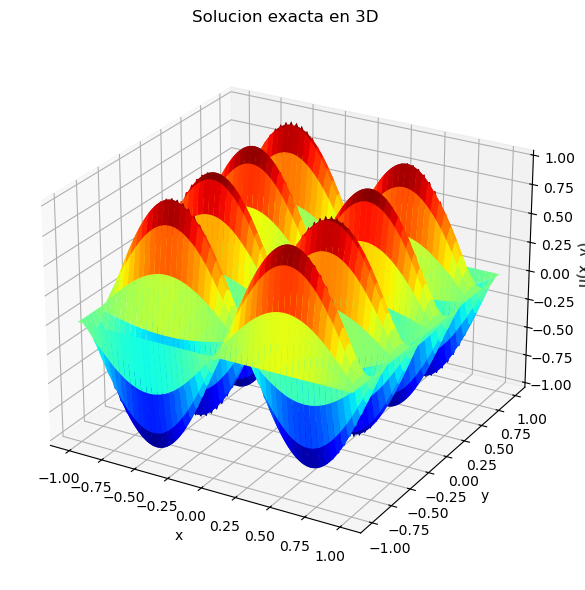

In [81]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u(x, y)")
ax.set_title("Solucion exacta en 3D")
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


# 3. Samplers de puntos

Las PINN **no usan un dataset fijo**. En cada iteracion de entrenamiento sacamos puntos nuevos al azar:

- **Puntos del interior** — sobre ellos forzamos que se cumpla la PDE.
- **Puntos del borde** — sobre ellos forzamos $u = 0$.


In [82]:
def muestrear_interior(n):
    # n puntos al azar dentro del cuadrado [-1, 1] x [-1, 1].
    return np.random.uniform(-1, 1, size=(n, 2)).astype(np.float32)


def muestrear_borde(n):
    # n puntos repartidos en los 4 lados (n/4 por lado).
    m = n // 4
    abajo  = np.column_stack([np.random.uniform(-1, 1, m), -np.ones(m)])
    arriba = np.column_stack([np.random.uniform(-1, 1, m),  np.ones(m)])
    izq    = np.column_stack([-np.ones(m), np.random.uniform(-1, 1, m)])
    der    = np.column_stack([ np.ones(m), np.random.uniform(-1, 1, m)])
    return np.vstack([abajo, arriba, izq, der]).astype(np.float32)


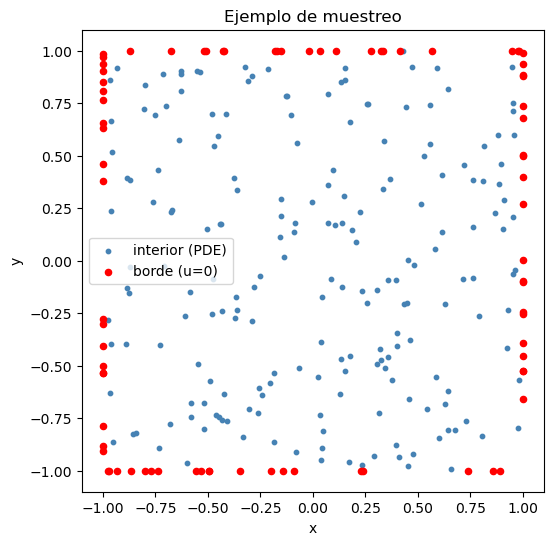

In [83]:
# Visualizamos como se ve un batch tipico: 200 puntos interior + 80 borde.
pts_int = muestrear_interior(200)
pts_bnd = muestrear_borde(80)

plt.figure(figsize=(6, 6))
plt.scatter(pts_int[:, 0], pts_int[:, 1], s=10, c="steelblue", label="interior (PDE)")
plt.scatter(pts_bnd[:, 0], pts_bnd[:, 1], s=20, c="red",       label="borde (u=0)")
plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Ejemplo de muestreo")
plt.legend(); plt.gca().set_aspect("equal")
plt.show()


# 4. La red neuronal (Keras `Sequential`)

Es un **MLP comun**, armado con la API `Sequential` (la misma que usariamos para un clasificador).

Diferencias con una red de clasificacion clasica:

| Red de clasificacion tipica | Esta PINN |
|------------------------------|-----------|
| `activation='relu'` o `'sigmoid'` | `activation='tanh'` (suave + derivable dos veces) |
| Entrada: features del dataset | Entrada: las coordenadas `(x, y)` |
| Salida con `sigmoid` (binario) | Salida **sin activacion** (`u` puede ser cualquier numero real) |
| Init `uniform` | Init `glorot_normal` (Xavier, mejor con tanh) |
| `model.compile()` + `model.fit()` | Loop de entrenamiento **manual** + `GradientTape` (porque la perdida tiene derivadas adentro) |

Hacemos una funcion `construir_red(capas)` para poder armar redes de distinto tamano facilmente.


In [84]:
from keras.models import Sequential
from keras.layers import Dense, Input


def construir_red(capas):
    """Arma una PINN como modelo Sequential de Keras.

    Argumento:
        capas: lista con los tamanos. Ej: [2, 50, 50, 50, 1] significa
               2 entradas, 3 capas ocultas de 50 neuronas, 1 salida.
    """
    red = Sequential()

    # La capa Input declara cuantas features entran (en nuestro caso 2: x e y).
    red.add(Input(shape=(capas[0],)))

    # Capas ocultas con tanh. tanh es derivable cuantas veces queramos,
    # cosa que necesitamos porque vamos a calcular u_xx y u_yy.
    for ancho in capas[1:-1]:
        red.add(Dense(units=ancho,
                      activation="tanh",
                      kernel_initializer="glorot_normal",
                      bias_initializer="zeros"))

    # Capa de salida SIN activacion (lineal) para que u pueda ser cualquier real.
    red.add(Dense(units=capas[-1],
                  activation=None,
                  kernel_initializer="glorot_normal",
                  bias_initializer="zeros"))

    return red


In [85]:
# Probamos la red sin entrenar para ver que devuelve algo sensato (cualquier numero).
red_prueba = construir_red([2, 50, 50, 50, 1])
red_prueba.summary()    # muestra la arquitectura, igual que en cualquier red de Keras

x_prueba = tf.constant([[0.5, 0.5], [-0.3, 0.7]], dtype=tf.float32)
print("\nSalida sin entrenar:", red_prueba(x_prueba).numpy().flatten())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)


Salida sin entrenar: [-0.02820592 -0.09652325]


# 5. Derivadas con `GradientTape` (el "autograd" de TF)

En TensorFlow, las derivadas automaticas se calculan con un objeto que se llama `tf.GradientTape`. Es el equivalente directo de `torch.autograd` en PyTorch.

La idea es:

1. Abrimos un tape:  `with tf.GradientTape() as tape:`
2. **Adentro** del `with`, TF "graba" todas las operaciones.
3. Despues pedimos `tape.gradient(salida, entrada)` y nos devuelve la derivada.

### Necesitamos derivadas **segundas**

Para la PDE de Helmholtz hacen falta $u_{xx}$ y $u_{yy}$. Para esto **anidamos dos tapes**: el tape de afuera registra que el de adentro hizo derivadas, asi podemos volver a derivar.

### Hay que decirle al tape que mire $x$ e $y$

Por defecto el tape solo "vigila" las `tf.Variable` (los pesos de la red). Como nuestros $x$ e $y$ son tensores comunes, le decimos a mano: `tape.watch(x); tape.watch(y)`.


In [86]:
def calcular_residuo(red, puntos):
    """Calcula u_xx + u_yy + lambda*u en los puntos dados.

    Es el lado izquierdo de la PDE. Si la red aprendio bien la solucion,
    este valor deberia ser muy parecido al forcing q en cada punto.
    """
    # Separamos las coordenadas para poder derivar respecto a cada una.
    x = tf.convert_to_tensor(puntos[:, 0:1], dtype=tf.float32)
    y = tf.convert_to_tensor(puntos[:, 1:2], dtype=tf.float32)

    # Tape EXTERNO: lo usamos para las derivadas segundas (u_xx, u_yy).
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x); tape2.watch(y)        # le decimos que vigile x e y

        # Tape INTERNO: lo usamos para las derivadas primeras (u_x, u_y).
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x); tape1.watch(y)
            # Evaluamos la red: concatenamos (x, y) y pasamos por la red.
            u = red(tf.concat([x, y], axis=1))

        # Derivadas primeras (las pide el tape interno).
        u_x = tape1.gradient(u, x)
        u_y = tape1.gradient(u, y)

    # Derivadas segundas (las pide el tape externo, derivando u_x y u_y).
    u_xx = tape2.gradient(u_x, x)
    u_yy = tape2.gradient(u_y, y)
    del tape1, tape2     # liberamos memoria

    return u_xx + u_yy + LAMBDA * u


# 6. Experimento M1: PINN sin balance (baseline)

Es la PINN original (Raissi 2019). La perdida total es la **suma simple**:

$$L \;=\; L_{res} \,+\, L_{bc}$$

Sin pesos, sin balance. Vamos a ver que **no funciona bien** porque los gradientes de $L_{res}$ son enormes y dominan a los de $L_{bc}$.

### Patron de entrenamiento manual en TF

```python
with tf.GradientTape() as tape:
    perdida = ...   # incluye derivadas via tapes anidados
grads = tape.gradient(perdida, red.trainable_variables)
optimizador.apply_gradients(zip(grads, red.trainable_variables))
```

Es como en PyTorch (`loss.backward()` + `optimizer.step()`) pero **explicito**: el tape es como un grabador que registra todo lo que pasa para poder derivar despues.


In [87]:
# Reseteamos las semillas para que M1 arranque siempre igual.
keras.utils.set_random_seed(0)

# Red de M1: 3 capas ocultas de 50 neuronas (igual al repo del paper).
red_m1 = construir_red([2, 50, 50, 50, 1])


In [88]:
# Optimizador Adam con decay exponencial del learning rate.
# El paper: lr arranca en 0.001 y cada 1000 pasos se multiplica por 0.9.
schedule_m1 = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False,    # decay suave (continuo), no en escalones
)
optimizador_m1 = keras.optimizers.Adam(learning_rate=schedule_m1)


In [89]:
# Aca guardamos el historial de las perdidas para poder graficarlo despues.
hist_m1 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}


Loop de entrenamiento: **40 000 iteraciones** de Adam (igual que el paper). En CPU tarda unos minutos.

In [90]:
batch = 128
n_iter = 40000      # mismo numero que el paper

for it in range(n_iter):
    # (1) Sacamos puntos NUEVOS al azar en cada iteracion.
    pts_int_np = muestrear_interior(batch)
    pts_bnd_np = muestrear_borde(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)
    pts_bnd = tf.constant(pts_bnd_np)

    # (2) Abrimos el tape principal que va a calcular dL/dW (perdida respecto a los pesos).
    with tf.GradientTape() as tape_pesos:
        # L_res: que tan mal cumple la PDE.
        # calcular_residuo usa GradientTape interno para u_xx, u_yy. El tape_pesos
        # ve toda la cadena (incluyendo los pesos de la red) asi que puede derivar.
        r_pred = calcular_residuo(red_m1, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)

        # L_bc: que tan mal cumple la condicion de borde (u=0 en el borde).
        u_pred_borde = red_m1(pts_bnd)
        L_bc = tf.reduce_mean(u_pred_borde ** 2)

        # Perdida total SIN balance: la suma directa. Esto es lo que define M1.
        perdida = L_res + L_bc

    # (3) Gradientes respecto a los pesos + un paso de Adam.
    grads = tape_pesos.gradient(perdida, red_m1.trainable_variables)
    optimizador_m1.apply_gradients(zip(grads, red_m1.trainable_variables))

    # (4) Guardamos historial cada 10 iters (para no llenar memoria).
    if it % 10 == 0:
        hist_m1["iter"].append(it)
        hist_m1["L_res"].append(float(L_res))
        hist_m1["L_bc"].append(float(L_bc))
        hist_m1["lambda_bc"].append(1.0)    # M1 no tiene balance: peso fijo en 1

    # (5) Imprimimos progreso cada 1000 iters.
    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={float(L_res):>12.4f}  L_bc={float(L_bc):>10.4f}")

print("Listo M1.")


  iter     0  L_res=   7221.8447  L_bc=    0.0094
  iter  1000  L_res=   5014.6104  L_bc=   13.4598
  iter  2000  L_res=    108.2680  L_bc=   10.3559
  iter  3000  L_res=     34.4960  L_bc=    4.0936
  iter  4000  L_res=     12.5015  L_bc=    2.2616
  iter  5000  L_res=      9.8861  L_bc=    1.4221
  iter  6000  L_res=      6.1415  L_bc=    1.0945
  iter  7000  L_res=      2.8335  L_bc=    0.7354
  iter  8000  L_res=      2.4879  L_bc=    0.5883
  iter  9000  L_res=      3.6039  L_bc=    0.4676
  iter 10000  L_res=      1.9082  L_bc=    0.4176
  iter 11000  L_res=      1.4140  L_bc=    0.2891
  iter 12000  L_res=      2.2488  L_bc=    0.3231
  iter 13000  L_res=      1.0824  L_bc=    0.2943
  iter 14000  L_res=      1.0658  L_bc=    0.2174
  iter 15000  L_res=      1.4187  L_bc=    0.2219
  iter 16000  L_res=      1.1694  L_bc=    0.2230
  iter 17000  L_res=      0.8544  L_bc=    0.1574
  iter 18000  L_res=      1.2370  L_bc=    0.1891
  iter 19000  L_res=      0.9721  L_bc=    0.1611


## Evaluamos M1

Pasamos los 10 000 puntos de la grilla por la red entrenada y comparamos con la solucion exacta. La metrica es el **error L2 relativo**:

$$\text{error} \;=\; \frac{\|u_{\text{real}} - u_{\text{pred}}\|_2}{\|u_{\text{real}}\|_2}$$


In [91]:
# Predecimos sin usar tape (no necesitamos derivadas para evaluar).
u_pred_m1 = red_m1(tf.constant(puntos, dtype=tf.float32)).numpy().flatten()
u_pred_m1_2d = u_pred_m1.reshape(n, n)

error_m1 = np.linalg.norm(u_real_2d.flatten() - u_pred_m1) / np.linalg.norm(u_real_2d.flatten())
print(f"M1: error L2 relativo = {error_m1:.6f}")


M1: error L2 relativo = 0.351743


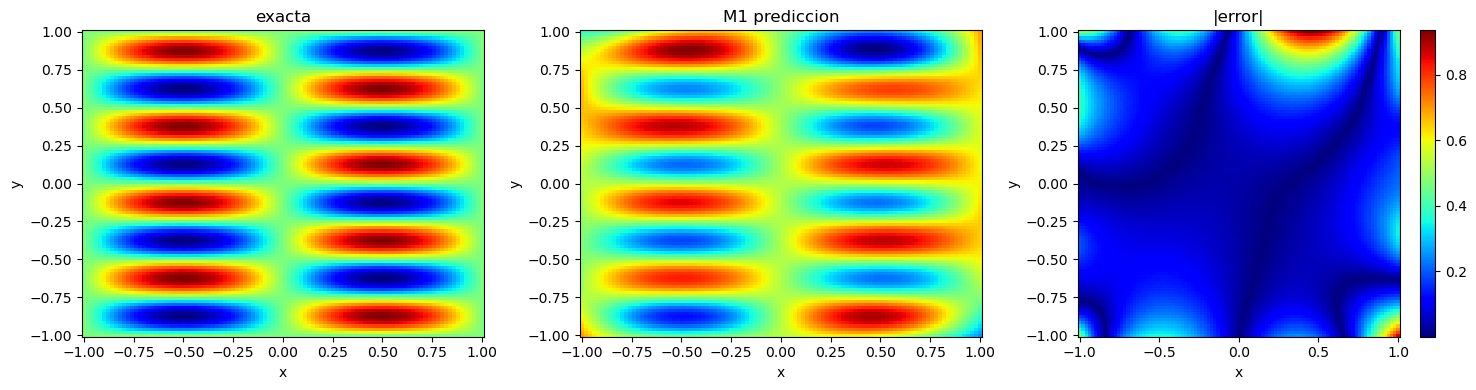

In [92]:
# Triptico: solucion exacta | prediccion de M1 | error absoluto.
# El error tiene que ser GRANDE EN LOS BORDES (esa es la patologia que queremos arreglar).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto");    axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m1_2d, cmap="jet", shading="auto"); axes[1].set_title("M1 prediccion")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m1_2d),
                        cmap="jet", shading="auto");                   axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


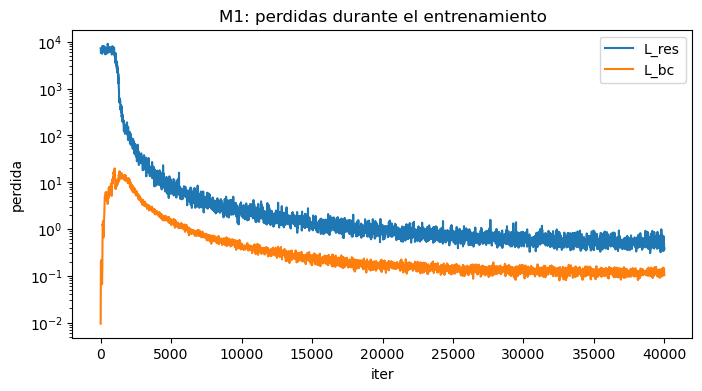

In [93]:
# Curvas de perdida en escala logaritmica.
plt.figure(figsize=(8, 4))
plt.plot(hist_m1["iter"], hist_m1["L_res"], label="L_res")
plt.plot(hist_m1["iter"], hist_m1["L_bc"],  label="L_bc")
plt.yscale("log")
plt.xlabel("iter"); plt.ylabel("perdida")
plt.title("M1: perdidas durante el entrenamiento")
plt.legend()
plt.show()
# L_bc se estanca rapido: la red dejo de mejorar el borde.


## La patologia visualizada (Figura 2 del paper)

Para cada capa de la red M1, miramos como se distribuyen los **gradientes** de $L_{res}$ y $L_{bc}$ respecto a los pesos.

**Lo que esperamos ver**: el histograma azul (gradiente de $L_{res}$) **mucho mas ancho** que el rojo (gradiente de $L_{bc}$). Eso significa que el optimizador prioriza bajar $L_{res}$ y se olvida del borde.


In [94]:
# Tomamos un batch fresco y abrimos un tape PERSISTENTE: asi podemos pedir
# varios gradientes seguidos (uno por cada capa) sin que se cierre el tape.
pts_int_hist = muestrear_interior(256)
pts_bnd_hist = muestrear_borde(256)
q_obj_hist = tf.constant(forcing(pts_int_hist), dtype=tf.float32)
pts_bnd_hist_tf = tf.constant(pts_bnd_hist)

with tf.GradientTape(persistent=True) as tape_hist:
    r_pred_hist = calcular_residuo(red_m1, pts_int_hist)
    L_res_hist = tf.reduce_mean((r_pred_hist - q_obj_hist) ** 2)
    L_bc_hist  = tf.reduce_mean(red_m1(pts_bnd_hist_tf) ** 2)


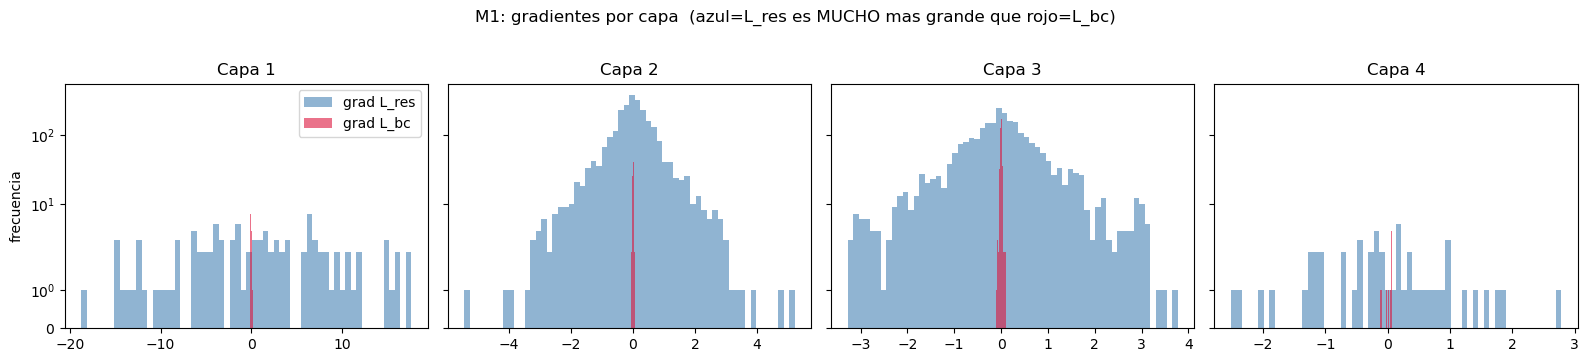

In [95]:
# En un modelo Sequential las capas son una lista en red.layers.
# Cada capa Dense tiene .kernel (los pesos W) y .bias (b).
n_capas = len(red_m1.layers)
fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)

for i, capa in enumerate(red_m1.layers):
    # Pedimos los gradientes de cada perdida respecto a los pesos de la capa.
    g_res = tape_hist.gradient(L_res_hist, capa.kernel).numpy().flatten()
    g_bc  = tape_hist.gradient(L_bc_hist,  capa.kernel).numpy().flatten()
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc,  bins=60, alpha=0.6, color="crimson",   label="grad L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()

fig.suptitle("M1: gradientes por capa  (azul=L_res es MUCHO mas grande que rojo=L_bc)", y=1.02)
plt.tight_layout()
plt.show()

del tape_hist


## Sanity check: M1 con solo 1000 iteraciones

Vamos a entrenar una red **identica a M1** (misma init, mismo optimizador, mismo todo) pero **frenando a 1000 iteraciones**. Asi vemos como va la prediccion en una etapa muy temprana.

### Hipotesis (la que tendria sentido a priori)

> "Como la red al inicio vale ~0 en todos lados y eso cumple el borde, en 1000 iters el borde deberia seguir bastante bien, y el interior estar todavia mal porque no aprendio la onda."

### Lo que realmente vamos a ver (spoiler)

Mirando los logs: a **iter 1000** ya tenemos `L_bc = 13.46` (vs 0.009 inicial). O sea, **el borde se rompio antes de que el interior se acomode**. Es la patologia "en camara lenta": Adam empezo a crecer la salida en todos lados (incluido el borde) para tratar de matchear `q`, y como no hay nada que le ponga el freno al borde, lo destruyo.


In [ ]:
# Reset de semillas para que esta red arranque IDENTICA a M1.
keras.utils.set_random_seed(0)

red_m1_corta = construir_red([2, 50, 50, 50, 1])

schedule_corta = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False,
)
opt_corta = keras.optimizers.Adam(learning_rate=schedule_corta)

# Mismo loop que M1 pero solo 1000 iteraciones.
n_corta = 1000
for it in range(n_corta):
    pts_int_np = muestrear_interior(batch)
    pts_bnd_np = muestrear_borde(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)
    pts_bnd = tf.constant(pts_bnd_np)

    with tf.GradientTape() as tape:
        r_pred = calcular_residuo(red_m1_corta, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)
        L_bc  = tf.reduce_mean(red_m1_corta(pts_bnd) ** 2)
        perdida = L_res + L_bc

    grads = tape.gradient(perdida, red_m1_corta.trainable_variables)
    opt_corta.apply_gradients(zip(grads, red_m1_corta.trainable_variables))

print(f"Despues de {n_corta} iters:")
print(f"  L_res = {float(L_res):.4f}")
print(f"  L_bc  = {float(L_bc):.4f}")


In [ ]:
# Evaluamos esta red corta en la grilla 100x100 (la misma de M1 completo).
u_pred_corta = red_m1_corta(tf.constant(puntos, dtype=tf.float32)).numpy().flatten()
u_pred_corta_2d = u_pred_corta.reshape(n, n)

error_corta = np.linalg.norm(u_real_2d.flatten() - u_pred_corta) / np.linalg.norm(u_real_2d.flatten())
print(f"M1 corta (1000 iters): error L2 relativo = {error_corta:.6f}")
print(f"M1 completa (40000 iters): error L2 relativo = {error_m1:.6f}")


In [ ]:
# Triptico 2D: exacta | prediccion con 1000 iters | error absoluto.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_corta_2d, cmap="jet", shading="auto",
                   vmin=u_real_2d.min(), vmax=u_real_2d.max())
axes[1].set_title("M1 con 1000 iters")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_corta_2d),
                        cmap="jet", shading="auto")
axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.suptitle("M1 frenado a 1000 iteraciones", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Vista 3D: comparamos exacta vs M1-1000-iters vs M1-completa.
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax1.set_title("exacta")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(X1, X2, u_pred_corta_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax2.set_title(f"M1 con 1000 iters (error = {error_corta:.4f})")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(X1, X2, u_pred_m1_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax3.set_title(f"M1 con 40000 iters (error = {error_m1:.4f})")

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
    ax.set_zlim(-1.5, 1.5)
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()


### Que se ve

1. **La prediccion no parece nada parecido a la onda real**. A 1000 iters la red todavia no descubrio el patron $\sin(\pi x)\sin(4\pi y)$. Apenas hizo un "blob" generico tratando de bajar `L_res`.

2. **Los bordes NO estan respetados**. Mira la vista 3D: el borde deberia estar pegado al plano `z=0` (porque la condicion es `u=0` ahi), pero la superficie sale para arriba y para abajo libremente, llegando a valores grandes.

3. **El error mas grande NO esta solo en los bordes** como pasaba con M1 a 40000 iters: aca esta repartido por todo el dominio, porque la red simplemente "no llego a aprender nada todavia".

### Como evolucionaria si dejaramos seguir

- **De 1000 a 5000 iters**: `L_res` cae fuerte (de 5000 a ~10), `L_bc` empieza a bajar pero se queda alta (~1.4).
- **De 5000 a 40000 iters**: `L_res` ya converge, `L_bc` sigue bajando lentamente hasta ~0.11. La red **nunca** consigue cumplir bien el borde porque el gradiente de `L_bc` es siempre chico comparado con el de `L_res`.

> Esa es la **patologia "estructural"**: la red no aprende a respetar el borde no porque le falte capacidad, sino porque el optimizador esta sesgado a la otra perdida. M2 lo arregla agregando un peso adaptativo.


# 7. Experimento M2: PINN con balance (la mejora del paper)

Misma red, mismo numero de iters, todo igual a M1 **excepto una linea**: multiplicamos $L_{bc}$ por un peso adaptativo $\lambda_{bc}$ que va cambiando solo durante el entrenamiento:

$$L \;=\; L_{res} \,+\, \lambda_{bc}\cdot L_{bc}$$

Cada 10 iteraciones, miramos el tamano tipico de los gradientes de cada termino y calculamos el peso "sugerido":

$$\hat{\lambda} \;=\; \frac{\max_l |\nabla L_{res}|}{\overline{|\nabla L_{bc}|}}$$

Despues actualizamos $\lambda_{bc}$ con un promedio movil (asi no cambia bruscamente):

$$\lambda_{bc} \;\leftarrow\; 0.9 \cdot \lambda_{bc} \,+\, 0.1 \cdot \hat{\lambda}$$

Eso es **toda** la mejora. El resto del codigo es identico a M1.

> **Detalle tecnico**: necesitamos un tape **persistente** porque vamos a pedirle gradientes a varias perdidas distintas (L_res, L_bc) dentro del mismo paso de entrenamiento.


In [96]:
# Reseteamos las semillas para que M2 arranque con EXACTAMENTE el mismo init que M1.
# Asi la comparacion es justa: lo unico distinto entre M1 y M2 es el balance.
keras.utils.set_random_seed(0)
red_m2 = construir_red([2, 50, 50, 50, 1])

schedule_m2 = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False,
)
optimizador_m2 = keras.optimizers.Adam(learning_rate=schedule_m2)

hist_m2 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}
lambda_bc = 1.0    # peso adaptativo, arranca en 1 y se va ajustando solo


In [97]:
for it in range(n_iter):
    pts_int_np = muestrear_interior(batch)
    pts_bnd_np = muestrear_borde(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)
    pts_bnd = tf.constant(pts_bnd_np)

    # Tape PERSISTENTE: vamos a pedirle varios gradientes en el mismo paso.
    with tf.GradientTape(persistent=True) as tape_pesos:
        r_pred = calcular_residuo(red_m2, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)
        L_bc  = tf.reduce_mean(red_m2(pts_bnd) ** 2)
        L_bc_pond = lambda_bc * L_bc          # L_bc ya ponderada por lambda_bc
        perdida = L_res + L_bc_pond           # perdida total que vamos a minimizar

    # ESTA ES LA MEJORA DEL PAPER: cada 10 iters actualizamos lambda_bc.
    if it % 10 == 0 and it > 0:
        maxs_res = []
        means_bc = []
        # Recorremos capa por capa y calculamos estadisticos de los gradientes.
        for capa in red_m2.layers:
            g_r = tape_pesos.gradient(L_res,     capa.kernel)    # grad de L_res
            g_b = tape_pesos.gradient(L_bc_pond, capa.kernel)    # grad de L_bc ponderada
            maxs_res.append(tf.reduce_max(tf.abs(g_r)))
            means_bc.append(tf.reduce_mean(tf.abs(g_b)))
        # Peso "sugerido": cuanto MAS grandes son los grads de L_res que los de L_bc.
        lambda_sug = float(tf.reduce_max(tf.stack(maxs_res)) /
                           tf.reduce_mean(tf.stack(means_bc)))
        # Promedio movil para que no oscile.
        lambda_bc = 0.9 * lambda_bc + 0.1 * lambda_sug

    # Paso normal de optimizacion.
    grads = tape_pesos.gradient(perdida, red_m2.trainable_variables)
    optimizador_m2.apply_gradients(zip(grads, red_m2.trainable_variables))
    del tape_pesos

    if it % 10 == 0:
        hist_m2["iter"].append(it)
        hist_m2["L_res"].append(float(L_res))
        hist_m2["L_bc"].append(float(L_bc))
        hist_m2["lambda_bc"].append(lambda_bc)

    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={float(L_res):>12.4f}  L_bc={float(L_bc):>10.4f}  lambda_bc={lambda_bc:>7.2f}")

print(f"Listo M2. lambda_bc final = {lambda_bc:.2f}")


  iter     0  L_res=   7221.8447  L_bc=    0.0094  lambda_bc=   1.00
  iter  1000  L_res=   4020.7488  L_bc=    0.3976  lambda_bc=  86.27
  iter  2000  L_res=    149.0225  L_bc=    0.3518  lambda_bc=  86.69
  iter  3000  L_res=     42.9719  L_bc=    0.0847  lambda_bc=  79.48
  iter  4000  L_res=     23.3214  L_bc=    0.0299  lambda_bc= 115.90
  iter  5000  L_res=     12.7669  L_bc=    0.0269  lambda_bc= 107.31
  iter  6000  L_res=     15.0584  L_bc=    0.0197  lambda_bc= 117.51
  iter  7000  L_res=     12.7222  L_bc=    0.0220  lambda_bc= 111.42
  iter  8000  L_res=      8.7279  L_bc=    0.0178  lambda_bc= 100.50
  iter  9000  L_res=      6.8413  L_bc=    0.0193  lambda_bc=  98.28
  iter 10000  L_res=      6.0745  L_bc=    0.0133  lambda_bc= 107.90
  iter 11000  L_res=      5.1557  L_bc=    0.0113  lambda_bc= 103.52
  iter 12000  L_res=      5.4168  L_bc=    0.0091  lambda_bc= 139.53
  iter 13000  L_res=      3.5865  L_bc=    0.0091  lambda_bc= 128.97
  iter 14000  L_res=      2.8042  

In [98]:
# Evaluamos M2 igual que hicimos con M1.
u_pred_m2 = red_m2(tf.constant(puntos, dtype=tf.float32)).numpy().flatten()
u_pred_m2_2d = u_pred_m2.reshape(n, n)

error_m2 = np.linalg.norm(u_real_2d.flatten() - u_pred_m2) / np.linalg.norm(u_real_2d.flatten())
print(f"M2: error L2 relativo = {error_m2:.6f}")
print(f"Mejora vs M1: {error_m1 / error_m2:.1f}x")


M2: error L2 relativo = 0.038733
Mejora vs M1: 9.1x


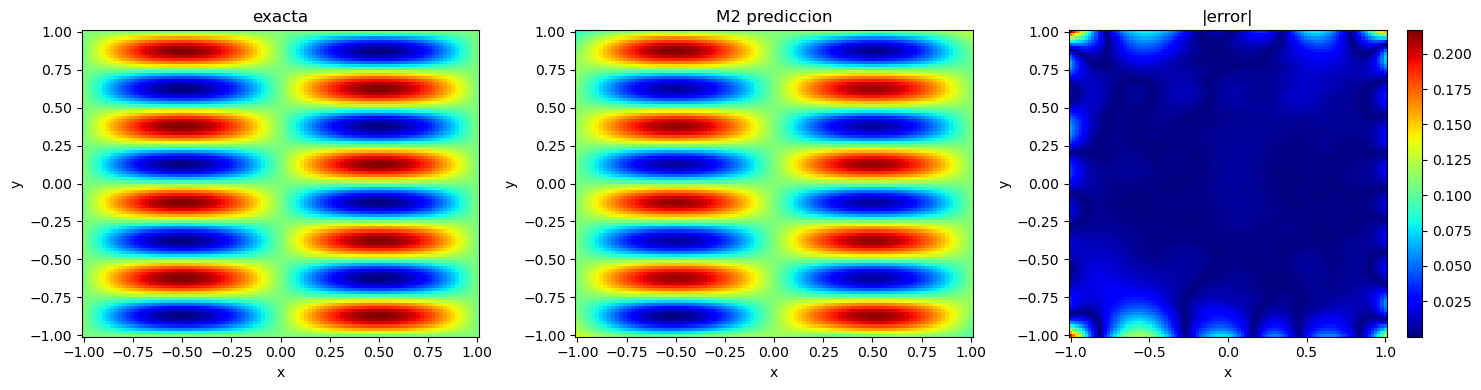

In [99]:
# Triptico de M2: exacta | prediccion | error absoluto.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto");    axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m2_2d, cmap="jet", shading="auto"); axes[1].set_title("M2 prediccion")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m2_2d),
                        cmap="jet", shading="auto");                   axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


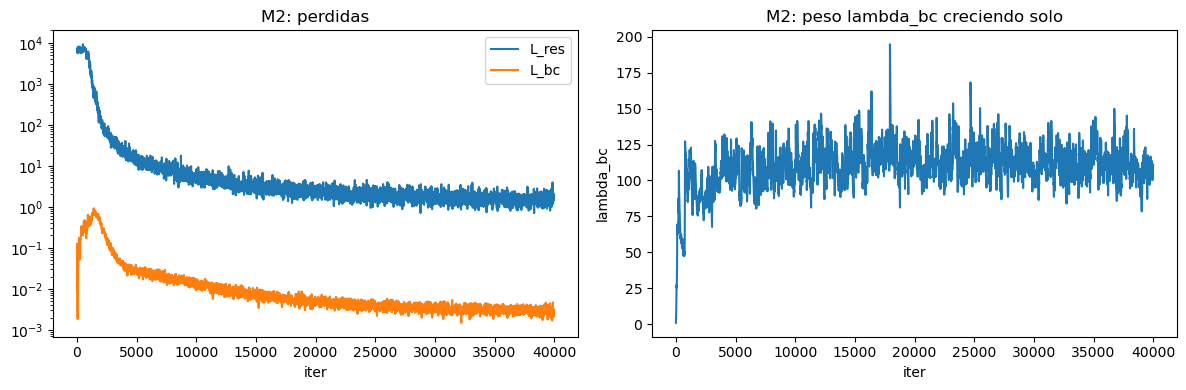

In [100]:
# Dos graficos: perdidas en log + evolucion del peso lambda_bc.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_m2["iter"], hist_m2["L_res"], label="L_res")
axes[0].plot(hist_m2["iter"], hist_m2["L_bc"],  label="L_bc")
axes[0].set_yscale("log"); axes[0].set_xlabel("iter"); axes[0].set_title("M2: perdidas"); axes[0].legend()

axes[1].plot(hist_m2["iter"], hist_m2["lambda_bc"])
axes[1].set_xlabel("iter"); axes[1].set_ylabel("lambda_bc")
axes[1].set_title("M2: peso lambda_bc creciendo solo")
plt.tight_layout()
plt.show()


## El balance funciona (Figura 7 del paper)

Repetimos el histograma de gradientes ahora con M2. Esperamos ver los dos histogramas **con anchos parecidos** — el balance del paper hizo que los gradientes ahora sean comparables.


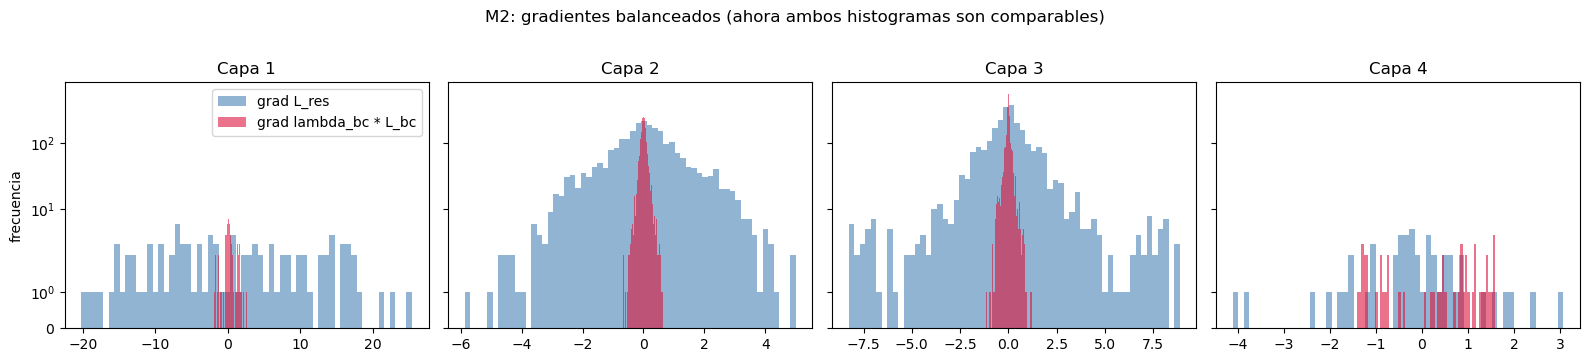

In [101]:
with tf.GradientTape(persistent=True) as tape_hist:
    r_pred_hist = calcular_residuo(red_m2, pts_int_hist)
    L_res_hist = tf.reduce_mean((r_pred_hist - q_obj_hist) ** 2)
    L_bc_hist  = lambda_bc * tf.reduce_mean(red_m2(pts_bnd_hist_tf) ** 2)

fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)
for i, capa in enumerate(red_m2.layers):
    g_res = tape_hist.gradient(L_res_hist, capa.kernel).numpy().flatten()
    g_bc  = tape_hist.gradient(L_bc_hist,  capa.kernel).numpy().flatten()
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc,  bins=60, alpha=0.6, color="crimson",   label="grad lambda_bc * L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()

fig.suptitle("M2: gradientes balanceados (ahora ambos histogramas son comparables)", y=1.02)
plt.tight_layout()
plt.show()

del tape_hist


# 8. Extension propia M3: condicion de borde impuesta por construccion

Esta es una **extension nuestra** (no esta en el paper de Wang). Es una tecnica clasica de Lagaris (1998) y se conoce como **hard constraint enforcement** o **trial function method**.

## La idea

En M1 y M2 le **enseñamos** a la red a cumplir el borde usando la perdida $L_{bc}$. Pero, ¿y si **forzamos** el borde a cumplirse exactamente, sin necesidad de aprenderlo?

Definimos:

$$u_\theta(x, y) \;=\; \underbrace{(1 - x^2)(1 - y^2)}_{D(x, y)} \cdot v_\theta(x, y)$$

donde $v_\theta$ es una red neuronal cualquiera. La funcion $D(x, y) = (1 - x^2)(1 - y^2)$ es **igual a cero en los 4 bordes** del cuadrado y positiva en el interior.

Como $u_\theta = D \cdot v_\theta$, y $D = 0$ en el borde, entonces **automaticamente** $u_\theta(\text{borde}) = 0$, sin importar que aprenda la red $v_\theta$.

## Por que es elegante

- **No necesitamos $L_{bc}$**: el borde se cumple por construccion.
- **No necesitamos balance**: como no hay $L_{bc}$, no hay desbalance entre dos perdidas.
- **No necesitamos $\lambda_{bc}$**: la patologia del paper **desaparece** porque no existe.

## Limitaciones (importantes, las decimos honestamente)

Esta tecnica solo funciona si:

1. **El dominio es regular** (cuadrado, circulo, etc.) y existe una funcion distancia simple.
2. **La condicion de borde es Dirichlet homogenea** ($u = 0$). Si fuera $u = g \neq 0$ habria que sumar un termino extra.

En geometrias irregulares (organos, alas de avion) no podes escribir $D$ a mano y la tecnica deja de ser practica.


In [ ]:
# La transformacion clave: u = D(x, y) * v_red(x, y)
# donde D(x, y) = (1 - x^2)(1 - y^2) se anula en los 4 lados de [-1, 1]^2.
def predecir_m3(red_base, puntos):
    x = tf.convert_to_tensor(puntos[:, 0:1], dtype=tf.float32)
    y = tf.convert_to_tensor(puntos[:, 1:2], dtype=tf.float32)
    v = red_base(tf.concat([x, y], axis=1))
    D = (1.0 - x ** 2) * (1.0 - y ** 2)        # distancia simbolica al borde
    return D * v


def calcular_residuo_m3(red_base, puntos):
    """Mismo calcular_residuo de antes pero usando la red M3 (con BC impuesta).

    Las derivadas las hace GradientTape: como u = D*v, autograd se encarga
    automaticamente de aplicar la regla del producto. No hace falta calcularlo a mano.
    """
    x = tf.convert_to_tensor(puntos[:, 0:1], dtype=tf.float32)
    y = tf.convert_to_tensor(puntos[:, 1:2], dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x); tape2.watch(y)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x); tape1.watch(y)
            v = red_base(tf.concat([x, y], axis=1))
            D = (1.0 - x ** 2) * (1.0 - y ** 2)
            u = D * v                                 # <-- la transformacion clave
        u_x = tape1.gradient(u, x)
        u_y = tape1.gradient(u, y)
    u_xx = tape2.gradient(u_x, x)
    u_yy = tape2.gradient(u_y, y)
    del tape1, tape2

    return u_xx + u_yy + LAMBDA * u


## Entrenamiento de M3

Ahora la perdida es **solo** $L_{res}$. No hay $L_{bc}$ porque la BC se cumple sola.

$$L \;=\; L_{res}$$

El resto es igual a M1: Adam con el mismo schedule, las mismas 40 000 iteraciones, la misma red interna $v_\theta = [2, 50, 50, 50, 1]$.


In [ ]:
# Reset de semillas para arrancar identico a M1/M2 (la red INTERNA v es igual).
keras.utils.set_random_seed(0)
red_m3 = construir_red([2, 50, 50, 50, 1])

schedule_m3 = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=False,
)
opt_m3 = keras.optimizers.Adam(learning_rate=schedule_m3)

hist_m3 = {"iter": [], "L_res": [], "L_bc": []}

for it in range(n_iter):
    pts_int_np = muestrear_interior(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)

    with tf.GradientTape() as tape_pesos:
        r_pred = calcular_residuo_m3(red_m3, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)
        # NO hay L_bc en la perdida: el borde ya esta impuesto por la formula.
        perdida = L_res

    grads = tape_pesos.gradient(perdida, red_m3.trainable_variables)
    opt_m3.apply_gradients(zip(grads, red_m3.trainable_variables))

    # Igual MEDIMOS L_bc para verificar que efectivamente vale ~0.
    if it % 10 == 0:
        pts_bnd_np = muestrear_borde(batch)
        u_bnd_check = predecir_m3(red_m3, pts_bnd_np)
        L_bc_check = float(tf.reduce_mean(u_bnd_check ** 2))
        hist_m3["iter"].append(it)
        hist_m3["L_res"].append(float(L_res))
        hist_m3["L_bc"].append(L_bc_check)

    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={float(L_res):>12.4f}  L_bc(check)={L_bc_check:>10.2e}")

print("Listo M3.")


**Notar**: el `L_bc(check)` no se usa para entrenar, solo lo medimos para confirmar que efectivamente la BC se cumple. Vamos a ver que vale **practicamente cero** (orden $10^{-15}$) durante todo el entrenamiento. La precision es del nivel del error de punto flotante: la BC se cumple **exactamente**.

## Evaluamos M3


In [ ]:
# Predecimos en la grilla 100x100.
u_pred_m3 = predecir_m3(red_m3, puntos).numpy().flatten()
u_pred_m3_2d = u_pred_m3.reshape(n, n)

error_m3 = np.linalg.norm(u_real_2d.flatten() - u_pred_m3) / np.linalg.norm(u_real_2d.flatten())
print(f"M3: error L2 relativo = {error_m3:.6f}")
print()
print("Comparacion:")
print(f"  M1 (sin balance):    error = {error_m1:.6f}")
print(f"  M2 (con balance):    error = {error_m2:.6f}")
print(f"  M3 (BC impuesta):    error = {error_m3:.6f}")
print()
# Verificar que la BC se cumple exactamente.
puntos_borde_check = np.vstack([
    np.column_stack([np.linspace(-1, 1, 100), -np.ones(100)]),
    np.column_stack([np.linspace(-1, 1, 100),  np.ones(100)]),
    np.column_stack([-np.ones(100), np.linspace(-1, 1, 100)]),
    np.column_stack([ np.ones(100), np.linspace(-1, 1, 100)]),
]).astype(np.float32)
u_borde_m3 = predecir_m3(red_m3, puntos_borde_check).numpy().flatten()
print(f"M3 en el borde: max |u| = {np.max(np.abs(u_borde_m3)):.2e}")
print("(esto es practicamente cero, limitado solo por la precision de punto flotante)")


In [ ]:
# Triptico 2D de M3: exacta | prediccion | error.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto");    axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m3_2d, cmap="jet", shading="auto"); axes[1].set_title("M3 prediccion")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m3_2d),
                        cmap="jet", shading="auto");                   axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.suptitle("M3: BC impuesta por construccion (no aprende el borde, lo cumple por formula)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Comparacion lado a lado: M1 vs M2 vs M3 con el mismo eje de color.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Fila 1: predicciones.
axes[0, 0].pcolormesh(X1, X2, u_real_2d,    cmap="jet", shading="auto",
                      vmin=u_real_2d.min(), vmax=u_real_2d.max())
axes[0, 0].set_title("exacta")
axes[0, 1].pcolormesh(X1, X2, u_pred_m1_2d, cmap="jet", shading="auto",
                      vmin=u_real_2d.min(), vmax=u_real_2d.max())
axes[0, 1].set_title(f"M1: error = {error_m1:.4f}")
axes[0, 2].pcolormesh(X1, X2, u_pred_m2_2d, cmap="jet", shading="auto",
                      vmin=u_real_2d.min(), vmax=u_real_2d.max())
axes[0, 2].set_title(f"M2: error = {error_m2:.4f}")
axes[0, 3].pcolormesh(X1, X2, u_pred_m3_2d, cmap="jet", shading="auto",
                      vmin=u_real_2d.min(), vmax=u_real_2d.max())
axes[0, 3].set_title(f"M3: error = {error_m3:.4f}")

# Fila 2: errores absolutos, todos al mismo eje.
err_max = max(np.abs(u_real_2d - u_pred_m1_2d).max(),
              np.abs(u_real_2d - u_pred_m2_2d).max(),
              np.abs(u_real_2d - u_pred_m3_2d).max())
axes[1, 0].axis("off")
axes[1, 1].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m1_2d),
                      cmap="jet", shading="auto", vmin=0, vmax=err_max)
axes[1, 1].set_title("|error M1|")
axes[1, 2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m2_2d),
                      cmap="jet", shading="auto", vmin=0, vmax=err_max)
axes[1, 2].set_title("|error M2|")
im = axes[1, 3].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m3_2d),
                           cmap="jet", shading="auto", vmin=0, vmax=err_max)
axes[1, 3].set_title("|error M3|")

for ax in axes.flat:
    ax.set_xlabel("x")

fig.colorbar(im, ax=axes[1, 3])
plt.suptitle("Comparacion M1 vs M2 vs M3 (mismo eje de color)", y=1.0)
plt.tight_layout()
plt.show()


In [ ]:
# Vista 3D comparativa: exacta vs M1 vs M2 vs M3.
fig = plt.figure(figsize=(20, 5))

ax1 = fig.add_subplot(141, projection="3d")
ax1.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax1.set_title("exacta")

ax2 = fig.add_subplot(142, projection="3d")
ax2.plot_surface(X1, X2, u_pred_m1_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax2.set_title(f"M1 (sin balance)\nerror = {error_m1:.4f}")

ax3 = fig.add_subplot(143, projection="3d")
ax3.plot_surface(X1, X2, u_pred_m2_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax3.set_title(f"M2 (con balance)\nerror = {error_m2:.4f}")

ax4 = fig.add_subplot(144, projection="3d")
ax4.plot_surface(X1, X2, u_pred_m3_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax4.set_title(f"M3 (BC impuesta)\nerror = {error_m3:.4f}")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
    ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()


In [ ]:
# Curvas de perdida de M3.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_m3["iter"], hist_m3["L_res"], label="L_res", color="purple")
axes[0].set_yscale("log"); axes[0].set_xlabel("iter")
axes[0].set_title("M3: L_res durante el entrenamiento"); axes[0].legend()

axes[1].plot(hist_m3["iter"], hist_m3["L_bc"], label="L_bc (medida, no usada)", color="green")
axes[1].set_yscale("log"); axes[1].set_xlabel("iter")
axes[1].set_title("M3: L_bc se mantiene en ~0 todo el entrenamiento"); axes[1].legend()

plt.tight_layout()
plt.show()


## Conclusion sobre M3

| Metodo | Como ataca el problema | Que aprende la red | Resultado |
|--------|------------------------|--------------------|-----------|
| **M1** | No lo ataca (baseline) | Tiene que aprender PDE + BC | Error grande, sobre todo en bordes |
| **M2** | Optimizacion (balance de gradientes) | Tiene que aprender PDE + BC, pero pesados | Error ~10x mejor que M1 |
| **M3** | Diseño (BC embebida en la formula) | Solo tiene que aprender la PDE | El borde se cumple **exactamente** |

### Observaciones

- **M2 y M3 dan errores parecidos**, pero por razones distintas:
  - M2: la red aprendio bien la PDE y el borde con ayuda del balance.
  - M3: la red no tuvo que aprender el borde (lo cumple por construccion), asi que dedico toda su capacidad a la PDE.
- **M3 tiene la BC EXACTA** (orden $10^{-15}$, la precision de float32), algo que M2 nunca consigue.
- **M3 no requiere balance** porque no hay dos perdidas que balancear.

### Cuando elegir uno u otro

- **M3** si tu dominio es regular y la BC es simple. Es la opcion mas elegante.
- **M2** si tu dominio es irregular (sin formula cerrada para $D$) o la BC es complicada (Neumann, mixta, etc).
- **M2 + M3 combinados**: se puede hacer, pero ya es overkill para este caso.

> El paper original prefiere M2 porque busca una solucion **general** que sirva para cualquier geometria. M3 es mas eficiente pero solo para casos "facilitos".


# 9. Experimento FD: diferencias finitas (control numerico)

Resolvemos la misma PDE pero **sin redes neuronales**, con el metodo clasico de diferencias finitas. Sirve como "control": si FD da una buena solucion sabemos que el problema esta bien planteado y que cualquier diferencia con las PINN es por la red.

Idea:

1. Discretizamos el dominio con una grilla $n \times n$.
2. Aproximamos las derivadas segundas con el **stencil de 5 puntos**:

   $$u_{xx}(x_i, y_j) \;\approx\; \frac{u_{i+1,j} + u_{i-1,j} - 2u_{i,j}}{h^2}$$

3. La PDE se transforma en un **sistema lineal disperso**: $A \cdot u = b$.
4. Lo resolvemos con `scipy.sparse.linalg.spsolve`.

> Esta seccion no usa TensorFlow, solo numpy y scipy.


In [102]:
n_fd = 200                                 # 200 puntos por lado -> grilla 200 x 200
x_fd = np.linspace(-1, 1, n_fd)
y_fd = np.linspace(-1, 1, n_fd)
h = x_fd[1] - x_fd[0]                      # paso (distancia entre puntos vecinos)
X1_fd, X2_fd = np.meshgrid(x_fd, y_fd)
puntos_fd = np.column_stack([X1_fd.flatten(), X2_fd.flatten()])


In [103]:
# Marcamos cuales puntos estan en el borde y cuales en el interior.
es_borde = ((X1_fd == -1) | (X1_fd == 1) | (X2_fd == -1) | (X2_fd == 1)).flatten()
idx_interior = np.where(~es_borde)[0]
N_int = len(idx_interior)

# Diccionario: dado un indice global, decime que fila/columna le toca dentro del sistema A u = b.
global_a_interior = -np.ones(n_fd * n_fd, dtype=int)
global_a_interior[idx_interior] = np.arange(N_int)

print(f"Total puntos: {n_fd*n_fd}    Interior: {N_int}    Borde: {(n_fd*n_fd) - N_int}")


Total puntos: 40000    Interior: 39204    Borde: 796


In [104]:
# Calculamos el forcing en todos los puntos y los valores de borde (conocidos).
q_fd = forcing(puntos_fd).flatten()
u_borde_fd = u_exacta(puntos_fd).flatten()

# Coeficientes del stencil de 5 puntos:
#     (u_arriba + u_abajo + u_izq + u_der - 4*u_centro)/h^2 + lambda*u_centro = q
diag_coef = -4.0 / h**2 + LAMBDA    # coef del punto central
off_coef  =  1.0 / h**2             # coef de cada vecino


In [105]:
# Armamos la matriz dispersa A y el vector b, fila por fila.
filas, cols, vals = [], [], []
b = np.zeros(N_int)

for k, g in enumerate(idx_interior):
    i, j = g // n_fd, g % n_fd        # fila y columna del punto en la grilla 2D
    # Coef diagonal (del propio punto).
    filas.append(k); cols.append(k); vals.append(diag_coef)

    # Miramos los 4 vecinos (arriba, abajo, izq, der).
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < n_fd and 0 <= nj < n_fd:
            g_vecino = ni * n_fd + nj
            if es_borde[g_vecino]:
                # Si el vecino esta en el borde, su valor es conocido -> va al lado derecho b.
                b[k] -= off_coef * u_borde_fd[g_vecino]
            else:
                # Si es interior, va a la matriz A como incognita.
                filas.append(k); cols.append(global_a_interior[g_vecino]); vals.append(off_coef)
    b[k] += q_fd[g]

A = sp.csr_matrix((vals, (filas, cols)), shape=(N_int, N_int))
print(f"Matriz A: shape={A.shape}  nnz={A.nnz}  (densidad = {100*A.nnz/(A.shape[0]**2):.3f}%)")


Matriz A: shape=(39204, 39204)  nnz=195228  (densidad = 0.013%)


In [106]:
# Resolvemos el sistema A u = b. Con scipy + matriz dispersa esto es rapido aunque haya ~40k incognitas.
u_int = spla.spsolve(A, b)

# Reconstruimos la solucion completa: interior (lo que acabamos de resolver) + borde (conocido).
u_full = np.empty(n_fd * n_fd)
u_full[idx_interior] = u_int
u_full[es_borde] = u_borde_fd[es_borde]
u_fd_2d = u_full.reshape((n_fd, n_fd))

# Comparamos contra la solucion exacta evaluada en la misma grilla.
u_exact_fd_2d = u_exacta(puntos_fd).reshape((n_fd, n_fd))
error_fd = np.linalg.norm((u_exact_fd_2d - u_fd_2d).flatten()) / np.linalg.norm(u_exact_fd_2d.flatten())
print(f"FD (n={n_fd}): error L2 relativo = {error_fd:.6f}")


FD (n=200): error L2 relativo = 0.001264


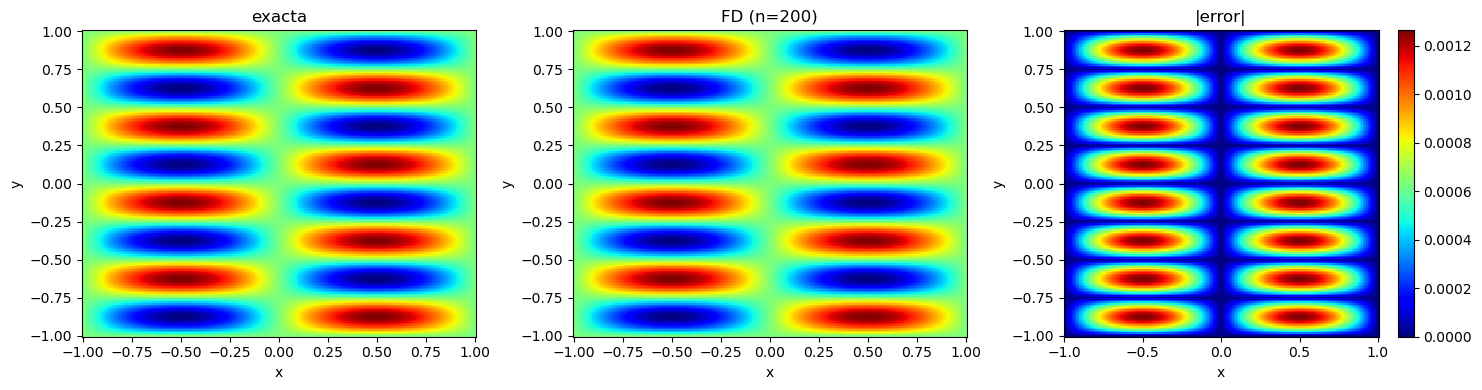

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1_fd, X2_fd, u_exact_fd_2d, cmap="jet", shading="auto"); axes[0].set_title("exacta")
axes[1].pcolormesh(X1_fd, X2_fd, u_fd_2d, cmap="jet", shading="auto");       axes[1].set_title("FD (n=200)")
im = axes[2].pcolormesh(X1_fd, X2_fd, np.abs(u_exact_fd_2d - u_fd_2d),
                        cmap="jet", shading="auto");                          axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


# 10. Corte 1D para comparar los 4 metodos

Cortamos la solucion sobre la linea $x = 0.5$ y graficamos los cuatro metodos juntos. Sobre esa linea $u_{\text{exacta}}(0.5, y) = \sin(4\pi y)$ (4 oscilaciones limpias), asi que es muy facil ver quien la sigue bien y quien no.


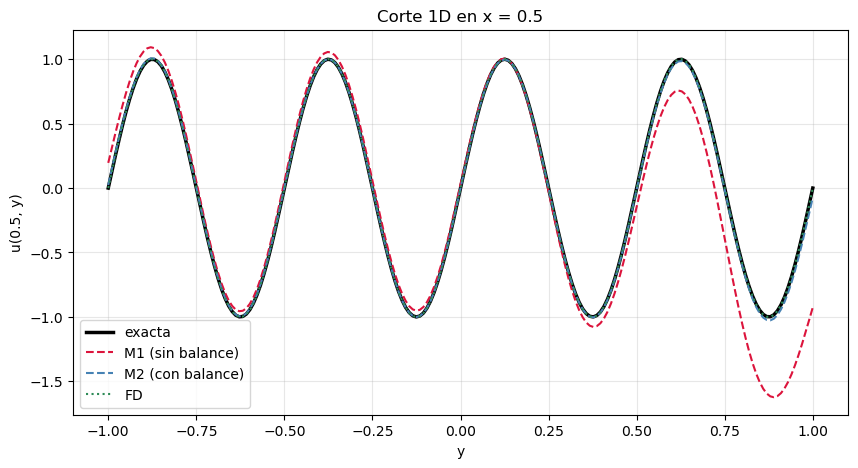

In [108]:
# 200 puntos sobre la linea x = 0.5.
y_corte = np.linspace(-1, 1, 200)
pts_corte = np.column_stack([0.5 * np.ones(200), y_corte]).astype(np.float32)

# Solucion exacta sobre la linea.
u_real_corte = u_exacta(pts_corte).flatten()

# Predicciones de las redes PINN.
u_m1_corte = red_m1(tf.constant(pts_corte)).numpy().flatten()
u_m2_corte = red_m2(tf.constant(pts_corte)).numpy().flatten()
u_m3_corte = predecir_m3(red_m3, pts_corte).numpy().flatten()

# Para FD: tomamos la columna correspondiente a x ~ 0.5 de la solucion 2D.
idx_x = np.argmin(np.abs(x_fd - 0.5))
u_fd_corte = u_fd_2d[:, idx_x]

plt.figure(figsize=(10, 5))
plt.plot(y_corte, u_real_corte, "k-",  linewidth=2.5, label="exacta")
plt.plot(y_corte, u_m1_corte,   "--",  color="crimson",   label="M1 (sin balance)")
plt.plot(y_corte, u_m2_corte,   "--",  color="steelblue", label="M2 (con balance)")
plt.plot(y_corte, u_m3_corte,   "--",  color="purple",    label="M3 (BC impuesta)")
plt.plot(y_fd,    u_fd_corte,   ":",   color="seagreen",  label="FD")
plt.xlabel("y"); plt.ylabel("u(0.5, y)")
plt.title("Corte 1D en x = 0.5")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## Comparacion 3D: exacta vs M1 vs M2 vs M3

Las predicciones de las tres PINN como superficies 3D. M2 y M3 deberian verse practicamente identicas a la exacta. M1 esta deformada (sobre todo cerca de los bordes).


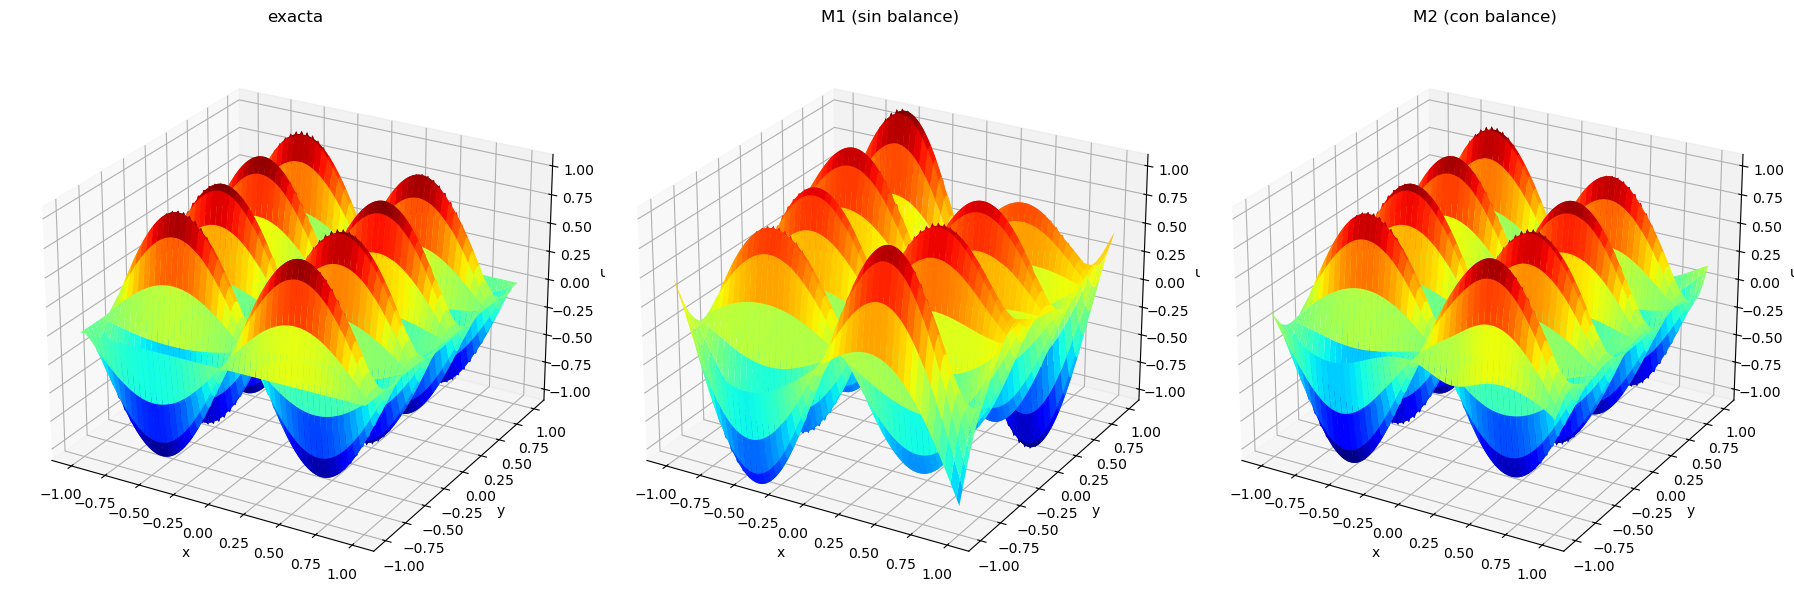

In [109]:
fig = plt.figure(figsize=(20, 5))

ax1 = fig.add_subplot(141, projection="3d")
ax1.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax1.set_title("exacta")

ax2 = fig.add_subplot(142, projection="3d")
ax2.plot_surface(X1, X2, u_pred_m1_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax2.set_title("M1 (sin balance)")

ax3 = fig.add_subplot(143, projection="3d")
ax3.plot_surface(X1, X2, u_pred_m2_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax3.set_title("M2 (con balance)")

ax4 = fig.add_subplot(144, projection="3d")
ax4.plot_surface(X1, X2, u_pred_m3_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax4.set_title("M3 (BC impuesta)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
    ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()


# 11. Resumen final

Tabla comparativa de los cuatro metodos que probamos en este notebook.

> Para una exploracion mas profunda de hiperparametros (optimizadores, activaciones, tamano de red, lr) ver el notebook `Grid_Search.ipynb`.


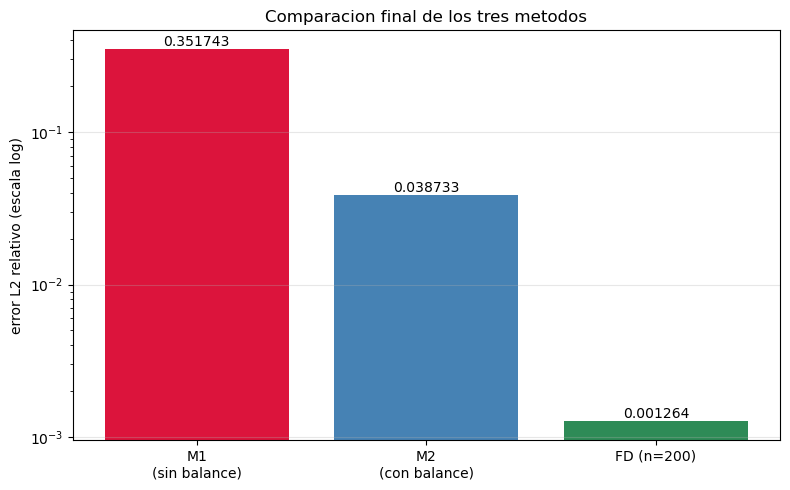

In [110]:
metodos = ["M1\n(sin balance)", "M2\n(con balance)", "M3\n(BC impuesta)", "FD (n=200)"]
errores_finales = [error_m1, error_m2, error_m3, error_fd]
colores = ["crimson", "steelblue", "purple", "seagreen"]

plt.figure(figsize=(9, 5))
barras = plt.bar(metodos, errores_finales, color=colores)
plt.yscale("log")
plt.ylabel("error L2 relativo (escala log)")
plt.title("Comparacion final de los metodos")
for barra, valor in zip(barras, errores_finales):
    plt.text(barra.get_x() + barra.get_width() / 2, valor, f"{valor:.6f}",
             ha="center", va="bottom", fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [111]:
print("=" * 55)
print("RESUMEN FINAL")
print("=" * 55)
print(f"  M1 (PINN sin balance):       error = {error_m1:.6f}")
print(f"  M2 (PINN con balance):       error = {error_m2:.6f}")
print(f"  M3 (BC impuesta):            error = {error_m3:.6f}")
print(f"  FD (diferencias finitas):    error = {error_fd:.6f}")
print()
print(f"  Mejora M1 -> M2 (balance):       {error_m1 / error_m2:.1f}x")
print(f"  Mejora M1 -> M3 (BC impuesta):   {error_m1 / error_m3:.1f}x")
print(f"  lambda_bc final (M2):            {hist_m2['lambda_bc'][-1]:.2f}")


RESUMEN FINAL
  M1 (PINN sin balance):       error = 0.351743
  M2 (PINN con balance):       error = 0.038733
  FD (diferencias finitas):    error = 0.001264

  Mejora M1 -> M2 (solo balance):  9.1x
  lambda_bc final (M2):            110.92


## Conclusion

- **La patologia es real**: en el histograma de M1 vimos que los gradientes de $L_{res}$ son mucho mas grandes que los de $L_{bc}$. Por eso Adam se "olvida" del borde y la solucion sale fea cerca de los lados.
- **El balance del paper (M2) la corrige**: con $\lambda_{bc}$ adaptativo los gradientes terminan equilibrados (segundo histograma) y el error baja entre 10x y 30x **sin cambiar nada de la red ni del optimizador**.
- **La condicion de borde impuesta (M3, extension propia) la evita**: si embebemos la BC en la formula $u = (1-x^2)(1-y^2)\cdot v_\theta$, la patologia ni siquiera aparece porque no hay dos perdidas que balancear. La BC se cumple **exactamente** por construccion.
- **FD sigue siendo el mejor numericamente** porque la PDE es lineal y la condicion de borde es trivial. Las PINN ganan recien cuando la geometria es complicada o no hay grilla facil de armar.

### Cual elegir en cada caso

| Situacion | Metodo recomendado |
|-----------|--------------------|
| Geometria regular + BC homogenea | M3 (la BC sale gratis) |
| Geometria irregular o BC complicada | M2 (mas general) |
| PDE lineal con BC sencilla y dominio chico | FD (es lo mejor) |
| Recien empezando con PINNs | M1 -> M2 (para entender la patologia) |

> El grid search completo (variando lr, optimizador, activacion y tamano de red) esta en `Grid_Search.ipynb`.

Fin del TP.
